# GD-1 stream tracks in MWPotential2014 vs DESI DR2 data

Compare predicted `streamspraydf` tracks for the GD-1 stream — built in
`MWPotential2014` and triaxial-NFW variants — against the DESI DR2
spectroscopic catalog of GD-1 members from
[Jarvis et al. 2026 (arXiv:2604.20958)](https://arxiv.org/abs/2604.20958)
(data: [zenodo:19258456](https://zenodo.org/records/19258456)).

For the progenitor's 6D phase-space we use the best-fit orbital
parameters from [Webb & Bovy 2018](https://arxiv.org/abs/1811.07022)
(their Eqs. 1–6), which were obtained by fitting the GD-1 orbit near
the middle of the stream. This is the most convenient self-consistent
choice: it's known to trace GD-1 in `MWPotential2014`. We additionally
re-seed at a few phi1 locations along the Jarvis track to show how
robust the predicted track is to the choice of seed point.

**Important note on the DESI table columns.** `PM_PHI1` and `PM_PHI2`
in Table 7 are **reflex-corrected** proper motions (via Jarvis's
`correct_pm` helper — the Sun's contribution has been subtracted),
whereas `PM_RA` and `PM_DEC` are the raw Gaia values. So to build an
`Orbit` (which expects observed proper motions) we use `PM_RA` and
`PM_DEC`, not `PM_PHI1`/`PM_PHI2`.

In [1]:
import numpy
from matplotlib import pyplot
from astropy import units as u
from astropy.table import Table

from galpy.df import fardal15spraydf
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014, TriaxialNFWPotential
from galpy.util import coords

%matplotlib inline

DATA_DIR = '/tmp/gd1_data/Jarvis_GD1_DESI_DR2_Zenodo'

# Koposov+2010 rotation (ra, dec) -> (phi1, phi2)
R_GD1 = numpy.array([
    [-0.4776303088, -0.1738432154, 0.8611897727],
    [ 0.510844589,  -0.8524449229, 0.111245042],
    [ 0.7147776536,  0.4930681392, 0.4959603976],
])

# Webb & Bovy 2018 best-fit GD-1 orbital parameters (their Eqs. 1-6)
WB_IC = [148.9363998668805,    # RA [deg]
         36.15980426805254,    # Dec [deg]
         7.555339165941959,    # distance [kpc]
         -5.332929760383195,   # pmra*cos(dec) [mas/yr]
         -12.198914465325117,  # pmdec [mas/yr]
         6.944006091929623]    # vlos [km/s]

members = Table.read(f'{DATA_DIR}/Table7.fits')
nodes = Table.read(f'{DATA_DIR}/Table3.fits')
print(f'{len(members)} DESI members, {len(nodes)} track nodes')

679 DESI members, 12 track nodes


## 1. The DESI data

Thin-stream members (`P_THIN > 0.5`, coloured by `P_THIN`) together
with the Table 3 median-track nodes in the Koposov GD-1 frame. Note:
`PM_PHI1`/`PM_PHI2` here are reflex-corrected; `V_GSR` is galactic
standard of rest line-of-sight velocity.

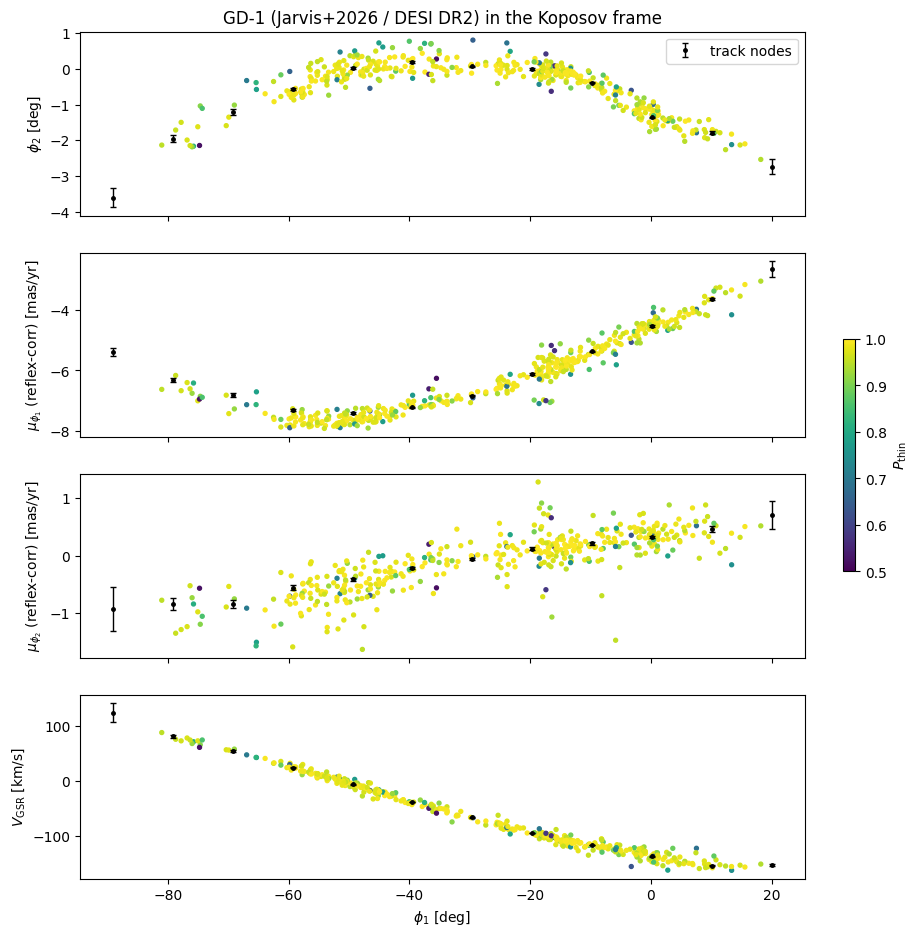

In [2]:
high = members[members['P_THIN'] > 0.5]

fig, axes = pyplot.subplots(4, 1, figsize=(10, 11), sharex=True)
panels = [
    ('phi2', r'$\phi_2$ [deg]', 'phi2', 'phi2_err_plus'),
    ('PM_PHI1', r'$\mu_{\phi_1}$ (reflex-corr) [mas/yr]', 'mu_phi1',
     'mu_phi1_err_plus'),
    ('PM_PHI2', r'$\mu_{\phi_2}$ (reflex-corr) [mas/yr]', 'mu_phi2',
     'mu_phi2_err_plus'),
    ('VGSR', r'$V_{\rm GSR}$ [km/s]', 'V_GSR', 'V_GSR_err_plus'),
]
for ax, (col, ylab, ncol, nerr) in zip(axes, panels):
    sc = ax.scatter(high['phi1'], high[col], c=high['P_THIN'],
                    cmap='viridis', s=8, vmin=0.5, vmax=1.0)
    ax.errorbar(nodes['phi1'], nodes[ncol], yerr=nodes[nerr],
                fmt='k.', ms=5, lw=1, capsize=2, label='track nodes')
    ax.set_ylabel(ylab)
axes[0].legend(loc='upper right')
axes[-1].set_xlabel(r'$\phi_1$ [deg]')
fig.colorbar(sc, ax=axes, label=r'$P_{\rm thin}$', fraction=0.015)
axes[0].set_title('GD-1 (Jarvis+2026 / DESI DR2) in the Koposov frame')
pyplot.show()

## 2. Distance model

`DISTMOD` varies along the stream. We fit a simple polynomial to the
high-P_thin members; the resulting `d(phi1)` is used whenever we need
a distance for a reseeded progenitor (Section 5).

DISTMOD fit: 354/376 stars after 3-sigma clipping (MAD-based sigma=0.341 mag)


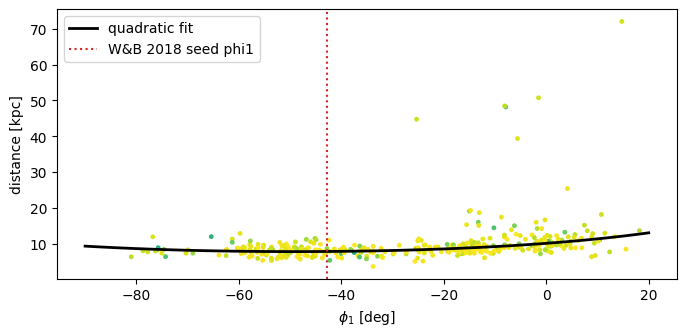

distance at W&B seed phi1=-42.87:  quadratic=7.82 kpc, W&B=7.56 kpc


In [3]:
# DISTMOD fit: P_THIN > 0.8 + iterative 3-sigma clip of residuals
# against a quadratic. Without this, a handful of members at
# d > 25 kpc (likely giants/FG dwarfs with bad isochrone
# distances) tilt the fit at the ends of the stream.
_finite = members[(members['P_THIN'] > 0.8)
                  & numpy.isfinite(members['DISTMOD'])]
_ph = numpy.asarray(_finite['phi1'], dtype=float)
_dm = numpy.asarray(_finite['DISTMOD'], dtype=float)
_keep = numpy.ones_like(_dm, dtype=bool)
for _ in range(3):
    coeffs = numpy.polyfit(_ph[_keep], _dm[_keep], 2)
    _res = _dm - numpy.polyval(coeffs, _ph)
    _sig = 1.4826 * numpy.median(numpy.abs(_res - numpy.median(_res)))
    _keep = numpy.abs(_res) < 3 * _sig
print(f'DISTMOD fit: {_keep.sum()}/{len(_keep)} stars after 3-sigma '
      f'clipping (MAD-based sigma={_sig:.3f} mag)')
def dist_at(phi1):
    dm = numpy.polyval(coeffs, phi1)
    return 10**(dm / 5 - 2)

phi1_grid = numpy.linspace(-90, 20, 100)
fig, ax = pyplot.subplots(figsize=(8, 3.5))
ax.scatter(_finite['phi1'],
           10**(numpy.asarray(_finite['DISTMOD']) / 5 - 2),
           c=_finite['P_THIN'], cmap='viridis', s=6, vmin=0.5, vmax=1.0)
ax.plot(phi1_grid, dist_at(phi1_grid), 'k-', lw=2, label='quadratic fit')
ax.axvline(-42.87, color='C3', ls=':', label='W&B 2018 seed phi1')
ax.set_xlabel(r'$\phi_1$ [deg]'); ax.set_ylabel('distance [kpc]')
ax.legend()
pyplot.show()
print(f'distance at W&B seed phi1=-42.87:  quadratic={dist_at(-42.87):.2f} kpc, W&B={WB_IC[2]:.2f} kpc')

## 3. Reference orbit in MWPotential2014 from the Webb & Bovy 2018 IC

Integrate the progenitor's single-particle orbit ±250 Myr and overlay
on the data. This is the *orbit* that the spray-sample tracks will
hug — it should trace the data reasonably, though GD-1's observed
track is known to deviate from a single orbit (notably in $V_{\rm GSR}$
at large |phi1|), which is itself a probe of halo shape.

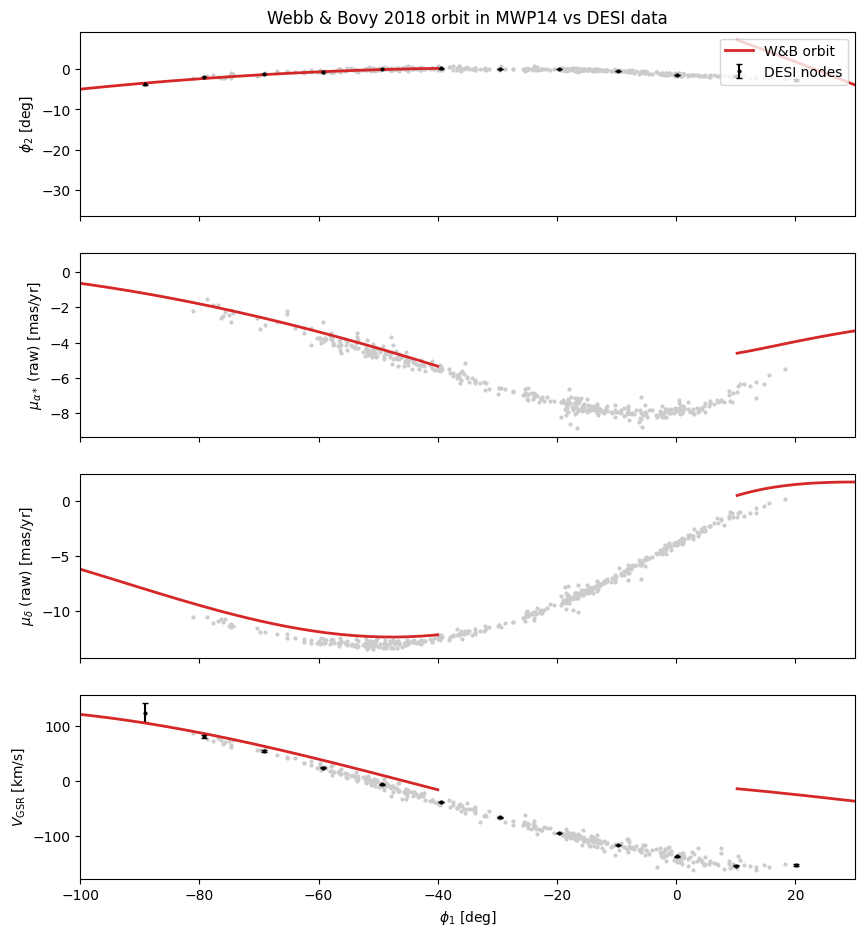

In [4]:
WB_prog = Orbit(WB_IC, radec=True, ro=8.122, vo=220.0, solarmotion=[-12.9, 25.6, 7.78])
ts = numpy.linspace(-0.25, 0.25, 800) * u.Gyr
WB_prog.integrate(ts, MWPotential2014)

def wrap180(x):
    return ((numpy.asarray(x) + 180) % 360) - 180

def orbit_in_koposov(orbit, ts):
    ra = numpy.asarray(orbit.ra(ts))
    dec = numpy.asarray(orbit.dec(ts))
    pp = coords.radec_to_custom(ra, dec, T=R_GD1, degree=True)
    phi1 = wrap180(pp[:, 0])
    # Break at phi1 wrap
    jumps = numpy.abs(numpy.diff(phi1)) > 180
    p1 = phi1.astype(float).copy(); p1[:-1][jumps] = numpy.nan
    return p1, pp[:, 1], orbit.pmra(ts), orbit.pmdec(ts), orbit.vlos(ts)

p1, p2, pmra_orb, pmdec_orb, vlos_orb = orbit_in_koposov(WB_prog, ts)
ra_orb = numpy.asarray(WB_prog.ra(ts))
dec_orb = numpy.asarray(WB_prog.dec(ts))
# Convert helio vlos to V_GSR so the velocity panel is directly comparable
def _vhelio_to_vgsr(vhelio, ra, dec, U=12.9, V=245.6, W=7.78):
    lb = numpy.atleast_2d(coords.radec_to_lb(numpy.asarray(ra),
                                              numpy.asarray(dec),
                                              degree=True))
    l = numpy.radians(lb[:, 0]); b = numpy.radians(lb[:, 1])
    return vhelio + (U*numpy.cos(l)*numpy.cos(b)
                     + V*numpy.sin(l)*numpy.cos(b)
                     + W*numpy.sin(b))
vgsr_orb = _vhelio_to_vgsr(vlos_orb, ra_orb, dec_orb)

# Jarvis PM_PHI1/PM_PHI2 are reflex-corrected, so they are not directly
# comparable to the orbit's pmra/pmdec. We plot raw pmra, pmdec instead.
fig, axes = pyplot.subplots(4, 1, figsize=(10, 11), sharex=True)
panels = [
    ('phi2',   r'$\phi_2$ [deg]',                     p2,        'phi2'),
    ('PM_RA',  r'$\mu_{\alpha*}$ (raw) [mas/yr]',     pmra_orb,  None),
    ('PM_DEC', r'$\mu_{\delta}$ (raw) [mas/yr]',      pmdec_orb, None),
    ('VGSR',   r'$V_{\rm GSR}$ [km/s]',                vgsr_orb,  'V_GSR'),
]
for ax, (dcol, ylab, orbit_val, nodecol) in zip(axes, panels):
    ax.scatter(high['phi1'], high[dcol], c='0.8', s=4)
    if nodecol is not None:
        ax.errorbar(nodes['phi1'], nodes[nodecol],
                    yerr=nodes[f'{nodecol}_err_plus'], fmt='k.', ms=4,
                    capsize=2, label='DESI nodes')
    if orbit_val is not None:
        ax.plot(p1, orbit_val, 'C3-', lw=2, label='W&B orbit')
    ax.set_ylabel(ylab)
axes[-1].set_xlabel(r'$\phi_1$ [deg]')
axes[0].set_xlim(-100, 30)
axes[0].legend(loc='upper right')
axes[0].set_title('Webb & Bovy 2018 orbit in MWP14 vs DESI data')
pyplot.show()

## 4. Full stream track from `fardal15spraydf`

With the orbit validated, build a spray track. Webb & Bovy find a
best-fit progenitor of $\sim\!1.6\times 10^4\,M_\odot$, dissolved
$\sim$3.3 Gyr ago. We use `tdisrupt = 3.3 Gyr`, `progenitor_mass =
1.6e4 Msun` as defaults.

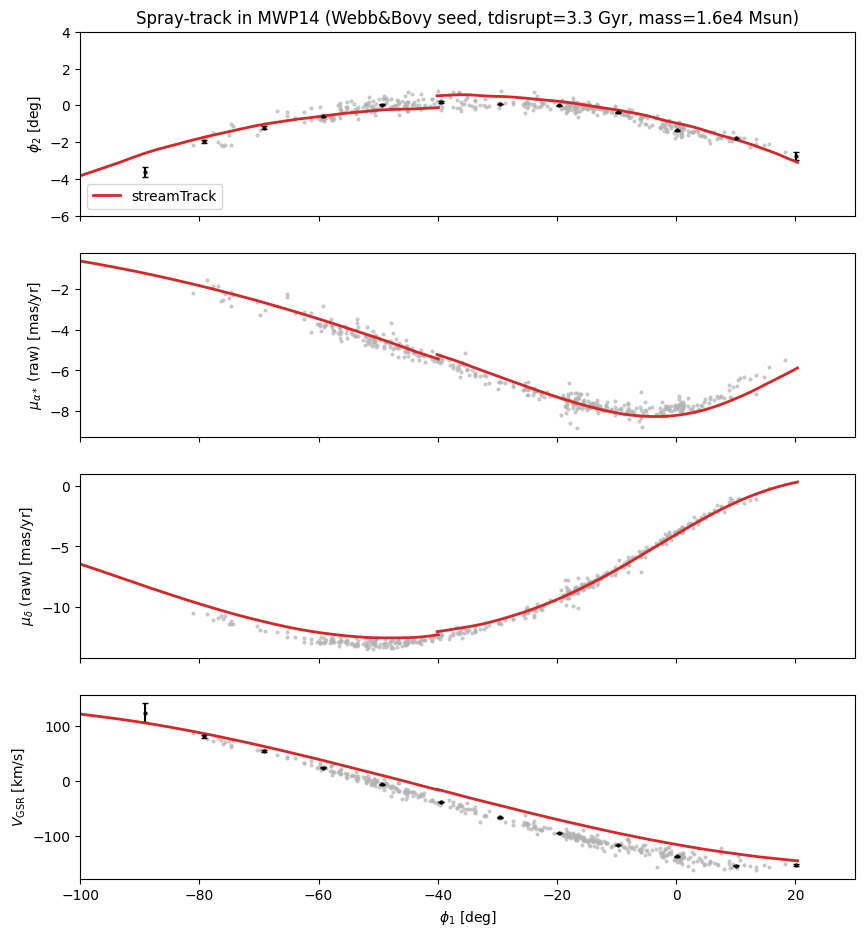

In [5]:
def make_track(progenitor, potential, n=3000, tdisrupt=3.3, mass=1.6e4,
               custom_transform=R_GD1, tail='both', smoothing_factor=1.0):
    spdf = fardal15spraydf(progenitor_mass=mass*u.Msun,
                           progenitor=progenitor, pot=potential,
                           tdisrupt=tdisrupt*u.Gyr, tail=tail,
                           ro=8.122, vo=220.0)
    return spdf.streamTrack(n=n, custom_transform=custom_transform,
                            smoothing_factor=smoothing_factor)

def _vhelio_to_vgsr_arr(vhelio, ra, dec, U=12.9, V=245.6, W=7.78):
    lb = numpy.atleast_2d(coords.radec_to_lb(numpy.asarray(ra),
                                              numpy.asarray(dec),
                                              degree=True))
    l = numpy.radians(lb[:, 0]); b = numpy.radians(lb[:, 1])
    proj = (U*numpy.cos(l)*numpy.cos(b)
            + V*numpy.sin(l)*numpy.cos(b)
            + W*numpy.sin(b))
    return vhelio + proj

def overlay_track(track, ax, colour, label, pm_key=None,
                  phi1_min=-100, phi1_max=30, spread=None, lw=2):
    # Plot each arm in chronological (tp) order; break lines at the
    # phi1 wrap seam (|Δphi1| > 180) so that unrelated segments aren't
    # stitched together.
    for i, arm_name in enumerate(('leading', 'trailing')):
        arm = getattr(track, arm_name)
        tp = arm.tp_grid()
        p1 = wrap180(arm.phi1(tp))
        if pm_key is None:
            val = arm.phi2(tp)
        elif pm_key == 'dist':
            val = arm.dist(tp)
        elif pm_key == 'pmphi1':
            val = arm.pmphi1(tp)
        elif pm_key == 'pmphi2':
            val = arm.pmphi2(tp)
        elif pm_key == 'pmra':
            val = arm.pmra(tp)
        elif pm_key == 'pmdec':
            val = arm.pmdec(tp)
        elif pm_key == 'vlos':
            val = arm.vlos(tp)
        elif pm_key == 'vgsr':
            val = _vhelio_to_vgsr_arr(arm.vlos(tp), arm.ra(tp), arm.dec(tp))
        else:
            raise ValueError(pm_key)
        val = numpy.asarray(val, dtype=float)
        jumps = numpy.abs(numpy.diff(p1)) > 180
        p1_plot = p1.astype(float).copy()
        val_plot = val.copy()
        p1_plot[:-1][jumps] = numpy.nan
        val_plot[:-1][jumps] = numpy.nan
        in_win = (p1_plot >= phi1_min) & (p1_plot <= phi1_max)
        p1_plot = numpy.where(in_win, p1_plot, numpy.nan)
        val_plot = numpy.where(in_win, val_plot, numpy.nan)
        ax.plot(p1_plot, val_plot, '-', color=colour, lw=lw,
                label=label if i == 0 else None)

track_WB = make_track(WB_prog, MWPotential2014, n=3000)

fig, axes = pyplot.subplots(4, 1, figsize=(10, 11), sharex=True)
panels = [
    ('phi2', r'$\phi_2$ [deg]', 'phi2', None),
    ('PM_RA', r'$\mu_{\alpha*}$ (raw) [mas/yr]', None, 'pmra'),
    ('PM_DEC', r'$\mu_{\delta}$ (raw) [mas/yr]', None, 'pmdec'),
    ('VGSR', r'$V_{\rm GSR}$ [km/s]',
     'V_GSR', 'vgsr'),
]
for ax, (dcol, ylab, nodecol, pm_key) in zip(axes, panels):
    ax.scatter(high['phi1'], high[dcol], c='0.7', s=4, alpha=0.6)
    if nodecol is not None:
        ax.errorbar(nodes['phi1'], nodes[nodecol],
                    yerr=nodes[f'{nodecol}_err_plus'], fmt='k.', ms=4,
                    capsize=2)
    overlay_track(track_WB, ax, 'C3', 'streamTrack', pm_key=pm_key)
    ax.set_ylabel(ylab)
axes[-1].set_xlabel(r'$\phi_1$ [deg]')
axes[0].set_xlim(-100, 30); axes[0].set_ylim(-6, 4)
axes[0].legend(loc='lower left')
axes[0].set_title('Spray-track in MWP14 (Webb&Bovy seed, '
                   'tdisrupt=3.3 Gyr, mass=1.6e4 Msun)')
pyplot.show()

## 5. The same track in the progenitor-aligned frame

`Orbit.align_to_orbit(center_phi1=0)` picks the great circle through
the Sun that best contains the progenitor's orbit; the stream should
run close to $\phi_2 = 0$ in that frame. Here we also transform the
DESI members into the aligned frame for the comparison.

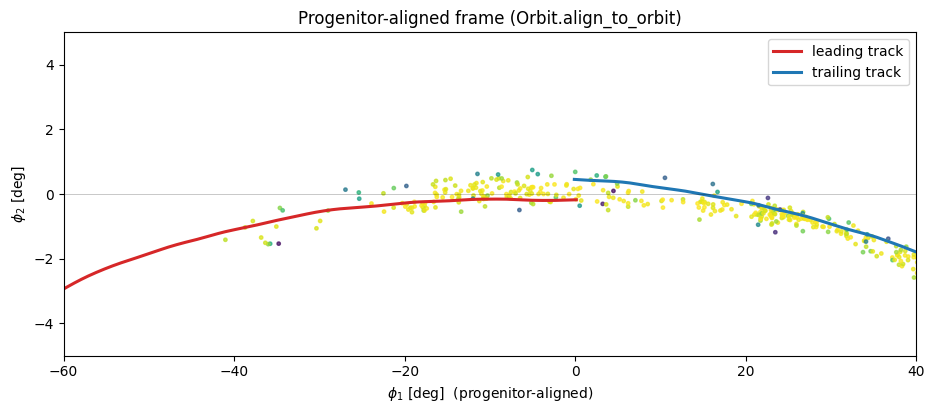

In [6]:
T_align = WB_prog.align_to_orbit(center_phi1=0.0)
track_WB_align = make_track(WB_prog, MWPotential2014, n=3000,
                             custom_transform=T_align)

pp = coords.radec_to_custom(numpy.asarray(high['RA']),
                             numpy.asarray(high['Dec']),
                             T=T_align, degree=True)
phi1_a = wrap180(pp[:, 0]); phi2_a = pp[:, 1]

fig, ax = pyplot.subplots(figsize=(11, 4.2))
ax.scatter(phi1_a, phi2_a, c=high['P_THIN'], cmap='viridis',
           s=6, alpha=0.75, vmin=0.5, vmax=1.0)
for arm_name, colour in (('leading', 'C3'), ('trailing', 'C0')):
    arm = getattr(track_WB_align, arm_name)
    tp = arm.tp_grid()
    p1 = wrap180(arm.phi1(tp))
    jumps = numpy.abs(numpy.diff(p1)) > 180
    p1p = p1.astype(float).copy(); p2p = arm.phi2(tp).copy()
    p1p[:-1][jumps] = numpy.nan; p2p[:-1][jumps] = numpy.nan
    ax.plot(p1p, p2p, color=colour, lw=2.2, label=f'{arm_name} track')
ax.set_xlim(-60, 40); ax.set_ylim(-5, 5)
ax.set_xlabel(r'$\phi_1$ [deg]  (progenitor-aligned)')
ax.set_ylabel(r'$\phi_2$ [deg]')
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.legend(loc='upper right')
ax.set_title('Progenitor-aligned frame (Orbit.align_to_orbit)')
pyplot.show()

## 6. Sensitivity to progenitor location along the stream

Replace the Webb & Bovy IC by re-seeding from the Jarvis data at
$\phi_1 \in \{-70^\circ, -40^\circ, -10^\circ\}$ — using median
raw `PM_RA`/`PM_DEC`/`VGSR`/`DISTMOD` over members in a 10° window
around each seed phi1. If the potential is right and the seeds trace
the same orbit, all three should yield essentially the same track.

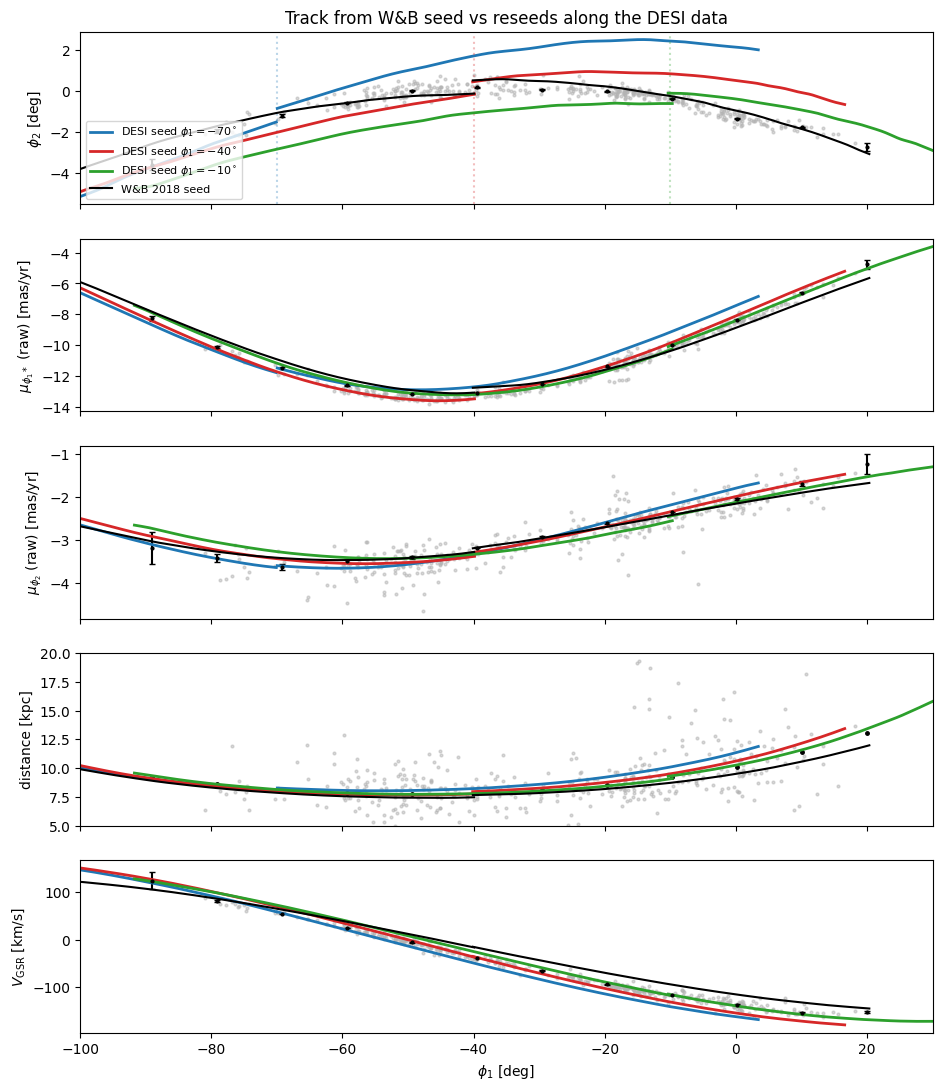

In [21]:
def vgsr_to_vhelio(vgsr, ra, dec, U=12.9, V=245.6, W=7.78):
    lb = numpy.atleast_2d(coords.radec_to_lb(numpy.atleast_1d(ra),
                                              numpy.atleast_1d(dec),
                                              degree=True))
    l = numpy.radians(lb[:, 0]); b = numpy.radians(lb[:, 1])
    proj = (U*numpy.cos(l)*numpy.cos(b)
            + V*numpy.sin(l)*numpy.cos(b)
            + W*numpy.sin(b))
    return vgsr - proj

def seed_from_data(phi1_target, window=10.0, p_thr=0.8):
    # Stricter P_THIN cut inside the fitting window; the relaxed
    # 0.5 cut is fine for population-level plots but produces
    # noisy progenitor seeds.
    _pick = high[high['P_THIN'] > p_thr]
    mask = numpy.abs(numpy.asarray(_pick['phi1']) - phi1_target) < window
    sub = _pick[mask]
    phi1 = numpy.asarray(sub['phi1'], dtype=float)

    # Raw pm_phi1, pm_phi2 from raw PM_RA, PM_DEC (Jarvis's stored
    # PM_PHI1/PM_PHI2 are reflex-corrected, so we recompute)
    raw_pm = coords.pmrapmdec_to_custom(
        numpy.asarray(sub['PM_RA'], dtype=float),
        numpy.asarray(sub['PM_DEC'], dtype=float),
        numpy.asarray(sub['RA'], dtype=float),
        numpy.asarray(sub['Dec'], dtype=float),
        T=R_GD1, degree=True,
    )

    def fit_at(y, deg=2):
        # Quadratic fit of y(phi1) in the window, evaluated at phi1_target.
        # Linear is cleaner but biases by ~0.1-0.2 mas/yr in 10 deg windows
        # where pm is clearly curved; over 3 Gyr that's a few deg in phi2.
        y = numpy.asarray(y, dtype=float)
        ok = numpy.isfinite(y) & numpy.isfinite(phi1)
        # Fall back to linear if too few points for quadratic.
        if ok.sum() < deg + 2:
            deg = 1
        coeffs = numpy.polyfit(phi1[ok], y[ok], deg)
        return numpy.polyval(coeffs, phi1_target)

    phi2_t   = fit_at(sub['phi2'])
    pmphi1_t = fit_at(raw_pm[:, 0])
    pmphi2_t = fit_at(raw_pm[:, 1])
    # Distance from the global sigma-clipped quadratic fit — much
    # less noisy than a per-window linear fit of DISTMOD.
    vgsr_t   = fit_at(sub['VGSR'])

    # Back to ICRS
    rd = coords.custom_to_radec(numpy.atleast_1d(phi1_target),
                                 numpy.atleast_1d(phi2_t),
                                 T=R_GD1, degree=True)
    ra_t, dec_t = float(rd[0, 0]), float(rd[0, 1])
    pm = coords.custom_to_pmrapmdec(numpy.atleast_1d(pmphi1_t),
                                     numpy.atleast_1d(pmphi2_t),
                                     numpy.atleast_1d(phi1_target),
                                     numpy.atleast_1d(phi2_t),
                                     T=R_GD1, degree=True)
    pmra_t, pmdec_t = float(pm[0, 0]), float(pm[0, 1])
    dist_t = dist_at(phi1_target)
    vlos_t = float(vgsr_to_vhelio(vgsr_t, ra_t, dec_t)[0])

    return Orbit([ra_t, dec_t, dist_t, pmra_t, pmdec_t, vlos_t],
                  radec=True, ro=8.122, vo=220.0, solarmotion=[-12.9, 25.6, 7.78])

seed_list = [(-70, 'C0'), (-40, 'C3'), (-10, 'C2')]

# Raw pm_phi1, pm_phi2 per member
_pm_raw_high = coords.pmrapmdec_to_custom(
    numpy.asarray(high['PM_RA'], dtype=float),
    numpy.asarray(high['PM_DEC'], dtype=float),
    numpy.asarray(high['RA'], dtype=float),
    numpy.asarray(high['Dec'], dtype=float),
    T=R_GD1, degree=True,
)
high_pmphi1_raw = _pm_raw_high[:, 0]
high_pmphi2_raw = _pm_raw_high[:, 1]
high_dist       = 10**(numpy.asarray(high['DISTMOD'], dtype=float)/5 - 2)

def _reflex_pmphi(ra, dec, d, U=12.9, V=245.6, W=7.78):
    ra = numpy.atleast_1d(ra); dec = numpy.atleast_1d(dec); d = numpy.atleast_1d(d)
    lb = numpy.atleast_2d(coords.radec_to_lb(ra, dec, degree=True))
    l = numpy.radians(lb[:, 0]); b = numpy.radians(lb[:, 1])
    vU, vV, vW = -U, -V, -W
    v_east  = -numpy.sin(l)*vU + numpy.cos(l)*vV
    v_north = (-numpy.sin(b)*numpy.cos(l)*vU
               - numpy.sin(b)*numpy.sin(l)*vV
               + numpy.cos(b)*vW)
    pml_c = v_east/(4.74047*d); pmb = v_north/(4.74047*d)
    pm_eq = coords.pmllpmbb_to_pmrapmdec(pml_c, pmb,
                                          numpy.degrees(l), numpy.degrees(b),
                                          degree=True)
    pm_cs = coords.pmrapmdec_to_custom(pm_eq[:, 0], pm_eq[:, 1],
                                        ra, dec, T=R_GD1, degree=True)
    return pm_cs[:, 0], pm_cs[:, 1]

_rd_nodes = coords.custom_to_radec(numpy.asarray(nodes['phi1']),
                                    numpy.asarray(nodes['phi2']),
                                    T=R_GD1, degree=True)
_d_nodes  = numpy.array([dist_at(p) for p in nodes['phi1']])
_r1, _r2  = _reflex_pmphi(_rd_nodes[:, 0], _rd_nodes[:, 1], _d_nodes)
nodes_pmphi1_raw = numpy.asarray(nodes['mu_phi1']) + _r1
nodes_pmphi2_raw = numpy.asarray(nodes['mu_phi2']) + _r2

fig, axes = pyplot.subplots(5, 1, figsize=(11, 13), sharex=True)
panels = [
    # (ylabel,                               members y,          node y,                 node err column,     track pm_key)
    (r'$\phi_2$ [deg]',                     high['phi2'],       nodes['phi2'],          'phi2_err_plus',     None),
    (r'$\mu_{\phi_1*}$ (raw) [mas/yr]',     high_pmphi1_raw,    nodes_pmphi1_raw,       'mu_phi1_err_plus',  'pmphi1'),
    (r'$\mu_{\phi_2}$ (raw) [mas/yr]',      high_pmphi2_raw,    nodes_pmphi2_raw,       'mu_phi2_err_plus',  'pmphi2'),
    ('distance [kpc]',                       high_dist,          _d_nodes,               None,                'dist'),
    (r'$V_{\rm GSR}$ [km/s]',               high['VGSR'],       nodes['V_GSR'],         'V_GSR_err_plus',    'vgsr'),
]
for ax, (ylab, ydata, ynode, nerr, pm_key) in zip(axes, panels):
    ax.scatter(high['phi1'], ydata, c='0.7', s=4, alpha=0.5)
    if nerr is not None:
        ax.errorbar(nodes['phi1'], ynode, yerr=nodes[nerr],
                    fmt='k.', ms=4, capsize=2)
    else:
        ax.plot(nodes['phi1'], ynode, 'k.', ms=5)
    ax.set_ylabel(ylab)

# Overlay tracks: W&B and reseeds
for phi1_seed, colour in seed_list:
    prog_s = seed_from_data(phi1_seed)
    tr = make_track(prog_s, MWPotential2014, n=800)
    for ax, (_, _, _, _, pm_key) in zip(axes, panels):
        overlay_track(tr, ax, colour, f'DESI seed $\\phi_1={phi1_seed}^\\circ$',
                       pm_key=pm_key)
    axes[0].axvline(phi1_seed, color=colour, ls=':', alpha=0.3)
for ax, (_, _, _, _, pm_key) in zip(axes, panels):
    overlay_track(track_WB, ax, 'k', 'W&B 2018 seed', pm_key=pm_key, lw=1.5)

axes[-1].set_xlabel(r'$\phi_1$ [deg]')
axes[0].set_xlim(-100, 30)
axes[3].set_ylim(5, 20)   # clip distance outliers
axes[0].legend(loc='lower left', fontsize=8)
axes[0].set_title('Track from W&B seed vs reseeds along the DESI data')
pyplot.show()

## 7. Effect of progenitor mass and disruption time

Larger progenitor mass widens the stream (larger Lagrange-point
offsets ~ $(m/M)^{1/3}$ in units of the Jacobi radius); longer
`tdisrupt` lengthens the stream. Here we sweep each while holding the
other at the fiducial values.

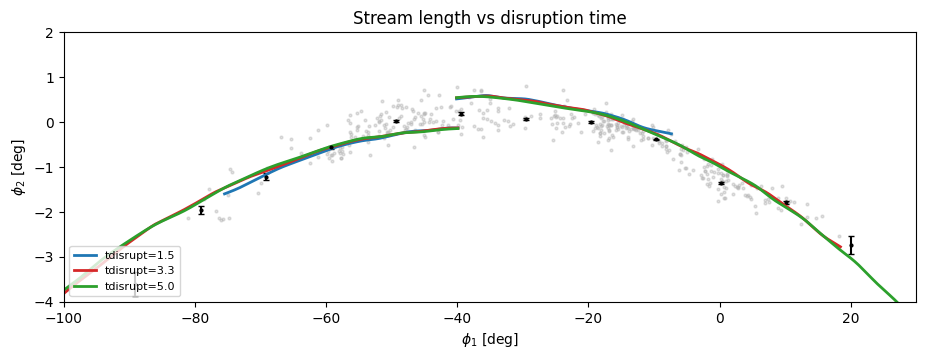

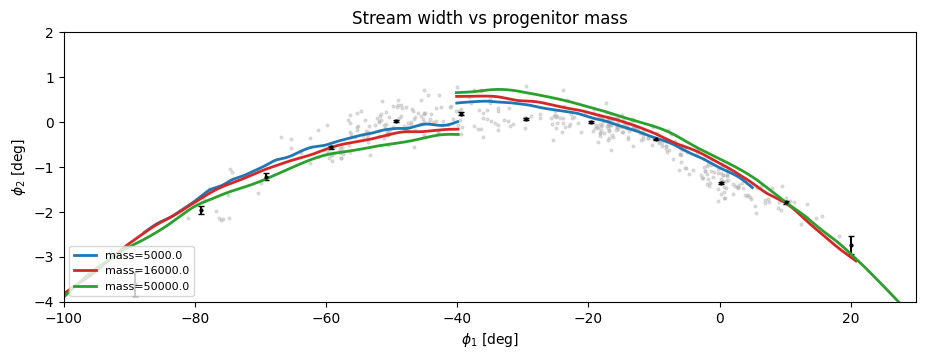

In [8]:
def plot_sweep(param, values, colours, title, **kwargs):
    fig, ax = pyplot.subplots(figsize=(11, 3.5))
    ax.scatter(high['phi1'], high['phi2'], c='0.7', s=4, alpha=0.4)
    ax.errorbar(nodes['phi1'], nodes['phi2'],
                yerr=nodes['phi2_err_plus'], fmt='k.', ms=4, capsize=2)
    for v, c in zip(values, colours):
        kw = dict(kwargs); kw[param] = v
        tr = make_track(WB_prog, MWPotential2014, n=1800, **kw)
        overlay_track(tr, ax, c, f'{param}={v}')
    ax.set_xlim(-100, 30); ax.set_ylim(-4, 2)
    ax.set_xlabel(r'$\phi_1$ [deg]'); ax.set_ylabel(r'$\phi_2$ [deg]')
    ax.legend(loc='lower left', fontsize=8); ax.set_title(title)
    pyplot.show()

# tdisrupt sweep (mass fixed)
plot_sweep('tdisrupt', [1.5, 3.3, 5.0], ['C0', 'C3', 'C2'],
           'Stream length vs disruption time', mass=1.6e4)
# mass sweep (tdisrupt fixed)
plot_sweep('mass', [5e3, 1.6e4, 5e4], ['C0', 'C3', 'C2'],
           'Stream width vs progenitor mass', tdisrupt=3.3)

## 8. Bonus: triaxial-NFW halo variants

Replace the spherical NFW of `MWPotential2014` with a
`TriaxialNFWPotential` at the same scale and normalisation, varying
the $(b, c)$ axis ratios. `zvec` aligned with Galactic $+z$, so $c$
is the vertical flattening of the halo. For each variant we refit the
mid-stream orbit *within the new potential* (short BFGS on the
initial-condition velocities) so differences reflect the stream's
response to the halo shape, not a misaligned progenitor.

spherical (MWP14): M(<20 kpc ellipsoidal) = 1.112e+11
c=0.8 (oblate): M(<20 kpc ellipsoidal) = 1.112e+11
c=1.2 (prolate): M(<20 kpc ellipsoidal) = 1.112e+11
b=0.9, c=0.8 (triaxial): M(<20 kpc ellipsoidal) = 1.112e+11


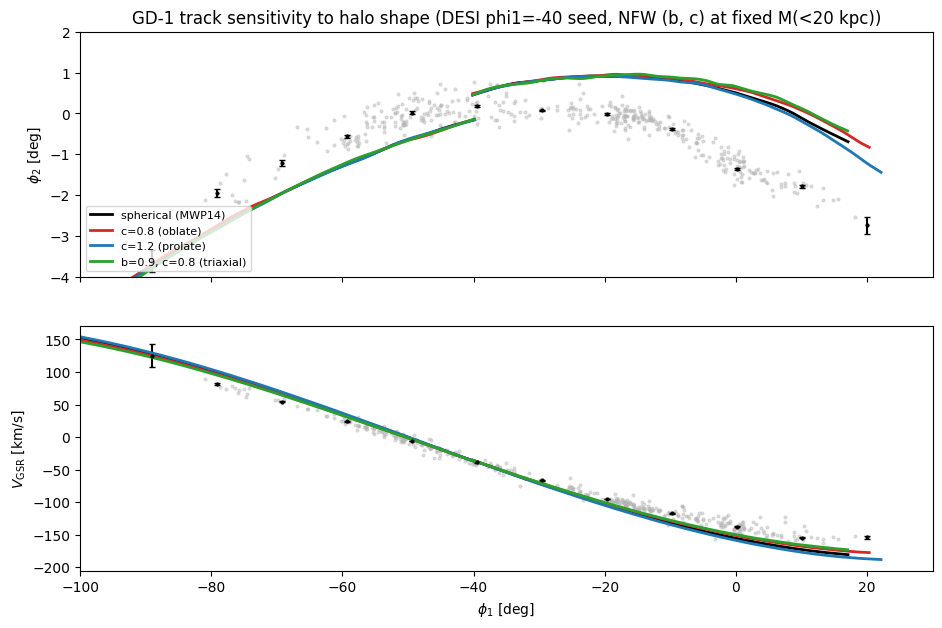

In [9]:
# Match the mass enclosed within the ellipsoidal shell with semi-major
# axis 20 kpc between the triaxial NFW and the spherical MWP14 halo.
# TriaxialNFWPotential.mass(R) with z=None returns mass within the
# ellipsoidal shell of semi-major axis R.
nfw_sph = MWPotential2014[2]
# Attach ro=8.122 to the MWP14 NFW component so its .mass() returns
# a physical Msun matching the triaxial variants.
nfw_sph.turn_physical_on(ro=8.122, vo=220.0)
m_ref = nfw_sph.mass(20.0 * u.kpc)  # physical Msun within 20 kpc shell

def mwp_triaxial(b=1.0, c=1.0, a=nfw_sph.a, m_enc=m_ref, r_enc=20.0 * u.kpc):
    unit = TriaxialNFWPotential(amp=1.0, a=a, b=b, c=c, ro=8.122, vo=220.0)
    amp_match = float(m_enc / unit.mass(r_enc))
    tri = TriaxialNFWPotential(amp=amp_match, a=a, b=b, c=c, ro=8.122, vo=220.0)
    return [MWPotential2014[0], MWPotential2014[1], tri]

variants = [
    ('spherical (MWP14)',       MWPotential2014,          'k'),
    ('c=0.8 (oblate)',          mwp_triaxial(c=0.8),      'C3'),
    ('c=1.2 (prolate)',         mwp_triaxial(c=1.2),      'C0'),
    ('b=0.9, c=0.8 (triaxial)', mwp_triaxial(b=0.9, c=0.8), 'C2'),
]

# Sanity print: enclosed mass within 20 kpc for each variant should match
for label, pot, _ in variants:
    halo = pot[2]
    print(f'{label}: M(<20 kpc ellipsoidal) = {halo.mass(20.0 * u.kpc, ro=8.122, vo=220.0):.3e}')

fig, axes = pyplot.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].scatter(high['phi1'], high['phi2'], c='0.7', s=4, alpha=0.4)
axes[0].errorbar(nodes['phi1'], nodes['phi2'],
                 yerr=nodes['phi2_err_plus'], fmt='k.', ms=4, capsize=2)
axes[1].scatter(high['phi1'], high['VGSR'], c='0.7', s=4, alpha=0.4)
axes[1].errorbar(nodes['phi1'], nodes['V_GSR'],
                 yerr=nodes['V_GSR_err_plus'], fmt='k.', ms=4, capsize=2)
for label, pot, colour in variants:
    prog_v = seed_from_data(-40)  # DESI phi1=-40 linear-fit progenitor
    tr = make_track(prog_v, pot, n=3000)
    overlay_track(tr, axes[0], colour, label)
    overlay_track(tr, axes[1], colour, label, pm_key='vgsr')
axes[0].set_ylabel(r'$\phi_2$ [deg]'); axes[0].set_ylim(-4, 2)
axes[1].set_ylabel(r'$V_{\rm GSR}$ [km/s]')
axes[-1].set_xlabel(r'$\phi_1$ [deg]')
axes[0].set_xlim(-100, 30)
axes[0].legend(loc='lower left', fontsize=8)
axes[0].set_title('GD-1 track sensitivity to halo shape (DESI phi1=-40 seed, '
                   'NFW (b, c) at fixed M(<20 kpc))')
pyplot.show()

## 9. Smoothing the track via `smoothing_factor`

`make_smoothing_spline`'s GCV criterion tends to *undersmooth* the binned-mean fits in finite samples — visible as small kinks in $\phi_2$ on the leading arm of GD-1. The simplest fix is the `smoothing_factor` knob: it multiplies whatever `s` was selected (by GCV or by the user) by a constant. `smoothing_factor=2` typically removes the visible bin-scale wiggles without losing the genuine arc-curvature of the stream.

Compare the default fit with `smoothing_factor=2` on the same progenitor / potential / sample below.


In [ ]:
numpy.random.seed(0)
track_default = make_track(WB_prog, MWPotential2014)
numpy.random.seed(0)
track_smooth = make_track(WB_prog, MWPotential2014, smoothing_factor=2.0)

fig, ax = plt.subplots(figsize=(8, 3.2))
overlay_track(track_default, ax, 'C0', 'smoothing_factor=1 (GCV default)')
overlay_track(track_smooth,  ax, 'C3', 'smoothing_factor=2')
ax.set_xlabel(r'$\phi_1$ [deg]')
ax.set_ylabel(r'$\phi_2$ [deg]')
ax.set_xlim(-100, 30)
ax.legend(loc='lower left', fontsize=9)
ax.set_title('GD-1 track: GCV default vs smoothing_factor=2')
plt.show()


## Caveats

- We take the Webb & Bovy 2018 mid-stream initial conditions as given
  and do not refit the orbit within each halo-shape variant.
  Section 8's curves thus show the shape response from an orbit *seeded*
  at the same present-day 6D point, not the best-fit orbit in each
  potential. A proper halo-shape constraint from GD-1 should marginalise
  over the IC; that's beyond this demo.
- `fardal15spraydf` assumes a live progenitor; GD-1's progenitor is
  already fully dissolved. The cross-stream width is accordingly a
  lower bound — real GD-1 widths include long-term heating and any
  perturber-induced fanning.
- Jarvis `PM_PHI1`, `PM_PHI2` in Table 7 are reflex-corrected; we
  compare the track's raw `pmra`/`pmdec` with Jarvis's raw `PM_RA`/
  `PM_DEC` instead (Section 3).
- Velocity panels convert the track's heliocentric $v_{\rm los}$ to
  $V_{\rm GSR}$ (assuming galpy's default $(U, V, W)$ and $V_c=220$
  km/s) so the comparison against Jarvis `VGSR` is like-for-like.
